# **1. Perkenalan Dataset**


Pada tahap ini, data dikumpulkan melalui proses **web scraping** dari laman **Google Maps** untuk mendapatkan ulasan (review) masyarakat mengenai layanan **rumah sakit di Kota Semarang**.

Alasan menggunakan Google Maps:
- Menjadi media utama masyarakat dalam memberikan penilaian layanan.
- Ulasan berisi opini kaya terkait pengalaman positif maupun negatif.
- Relevan untuk analisis sentimen dan opini publik.

Atribut yang berhasil dikumpulkan antara lain:
- 🏥 **ID Rumah Sakit** : Penanda unik setiap rumah sakit.  
- 🏷️ **Nama Rumah Sakit** : Identitas rumah sakit.  
- 🏨 **Tipe Rumah Sakit** : Umum atau spesialis.  
- 👤 **Nama Pengguna** : Identitas pemberi ulasan.  
- 💬 **Teks Ulasan** : Opini/komentar pengguna.  

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Pastikan stopwords tersedia
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('indonesian'))

# Install Sastrawi (jika belum terpasang)
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

from wordcloud import WordCloud
import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.0 MB/s eta 0:00:00


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/TA - Sentimen Analysis dan Opini Ulasan Rumah Sakit/new/dataset_rs.csv', delimiter=';')
df.head()

,id_rs,rumah_sakit,tipe_rs,nama,ulasan
0,3374123,RS Dr. Amino Gondohutomo,A,bam Rustano,Dokter untu og ngamukan
1,3374123,RS Dr. Amino Gondohutomo,A,Nike Dewanti,Setelah saya berkonsultasi dengan yg lebih pro...
2,3374123,RS Dr. Amino Gondohutomo,A,Claudia Noviantiy,Pelayanan sangat memuaskan
3,3374123,RS Dr. Amino Gondohutomo,A,Ma'ruf Aji Nugroho,Itu keren
4,3374123,RS Dr. Amino Gondohutomo,A,Muhammad Yuga Syahputra,Nais banget!!


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
#Type your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16346 entries, 0 to 16345
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_rs        16346 non-null  int64 
 1   rumah_sakit  16346 non-null  object
 2   tipe_rs      16346 non-null  object
 3   nama         16346 non-null  object
 4   ulasan       16346 non-null  object
dtypes: int64(1), object(4)
memory usage: 638.6+ KB


In [ ]:
df.isnull().sum()

,0
id_rs,0
rumah_sakit,0
tipe_rs,0
nama,0
ulasan,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['rumah_sakit'].value_counts()

,count
rumah_sakit,
RS Sultan Agung,1485
RSUD Wongsonegoro,1416
RS St. Elisabeth Semarang,1268
RS Primaya,1125
RS Panti Wilasa,1070
RS Hermina Pandanaran,939
RS Panti Wilasa II,917
RSUP Dr. Kariadi,917
RS Muhammadiyah Roemani,893


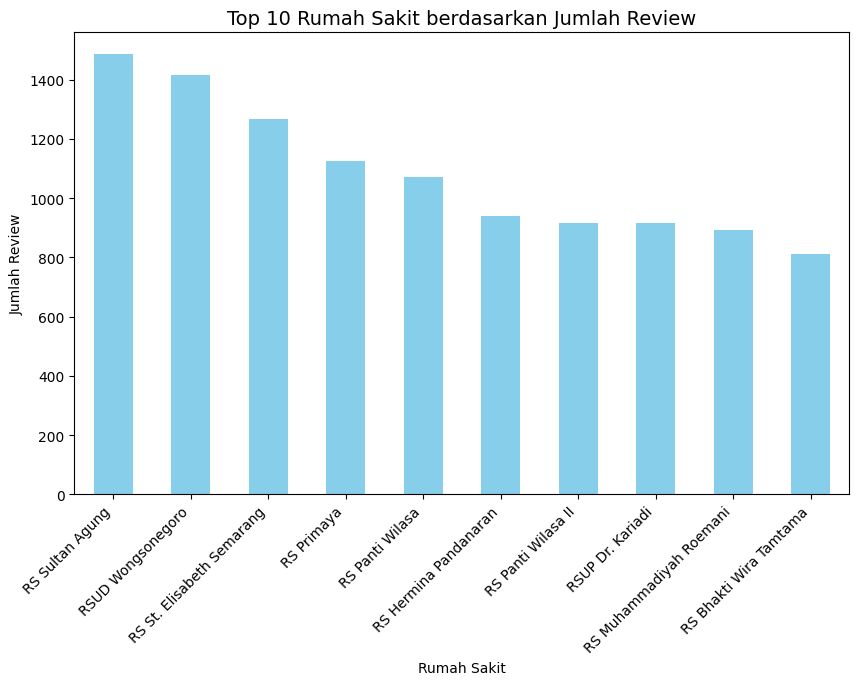

In [ ]:
# --- 1. Distribusi Jumlah Review per Rumah Sakit ---
plt.figure(figsize=(10,6))
df['rumah_sakit'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Rumah Sakit berdasarkan Jumlah Review", fontsize=14)
plt.xlabel("Rumah Sakit")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=45, ha='right')
plt.show()

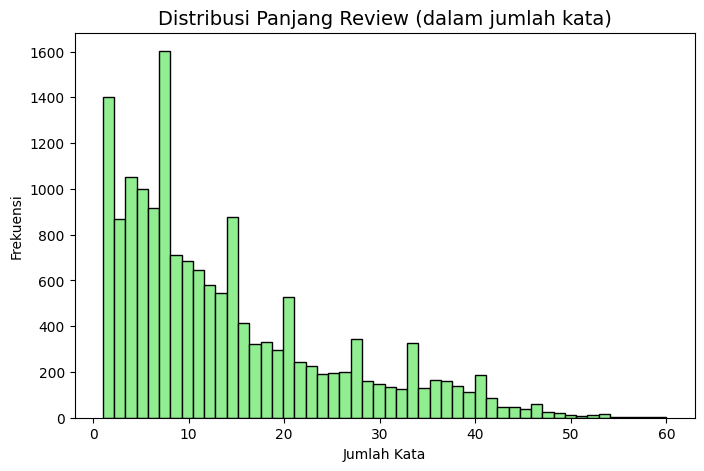

In [ ]:
# --- 2. Panjang Review ---
df['review_length'] = df['ulasan'].astype(str).apply(lambda x: len(x.split()))
plt.figure(figsize=(8,5))
plt.hist(df['review_length'], bins=50, color='lightgreen', edgecolor='black')
plt.title("Distribusi Panjang Review (dalam jumlah kata)", fontsize=14)
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

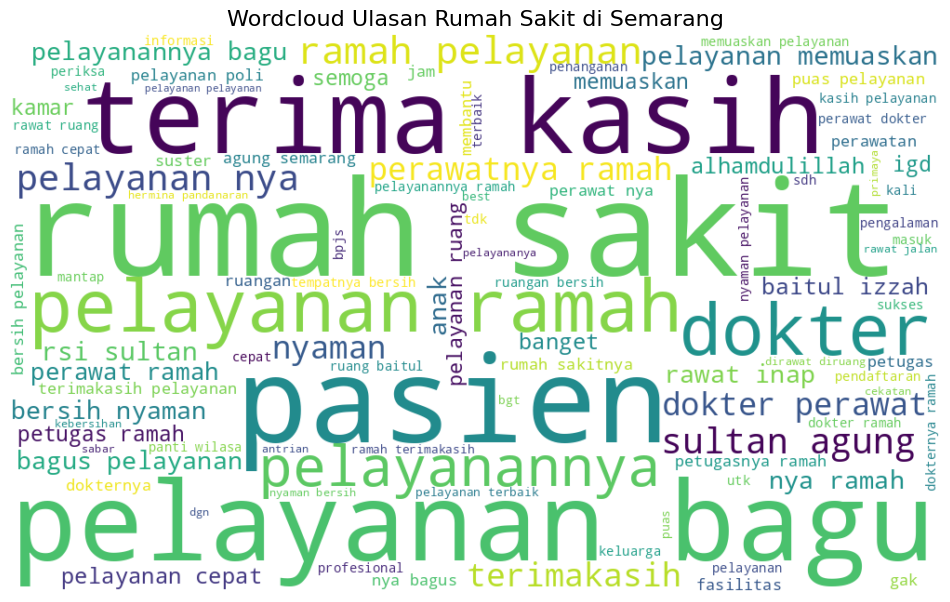

In [ ]:
# --- 3. Wordcloud Kata yang Sering Muncul ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hanya huruf
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(words)

text_corpus = " ".join(df['ulasan'].dropna().apply(clean_text))

wordcloud = WordCloud(width=1000, height=600, background_color="white",
                      colormap="viridis", max_words=100).generate(text_corpus)

plt.figure(figsize=(12,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud Ulasan Rumah Sakit di Semarang", fontsize=16)
plt.show()

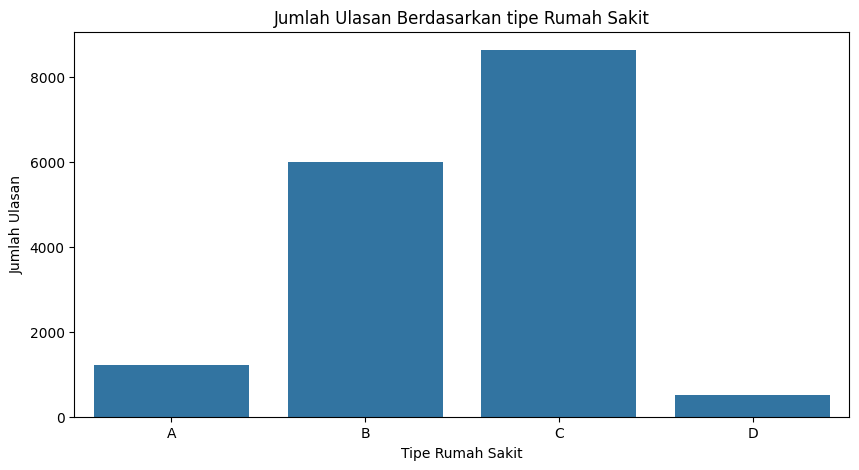

In [ ]:
# --- 4. Ulasan per Tipe Rumah Sakit ---
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='tipe_rs')
plt.title('Jumlah Ulasan Berdasarkan tipe Rumah Sakit')
plt.xlabel('Tipe Rumah Sakit')

plt.ylabel('Jumlah Ulasan')
plt.show()

## Insight

### 1. Informasi Dasar DataFrame (`df.info()`)

- **Kesimpulan Utama:** Dataset ini dalam kondisi baik, lengkap, dan siap untuk dianalisis lebih lanjut. Tidak ditemukan adanya nilai yang hilang (missing values).  
- **Ukuran Data:** Terdapat **16.346 baris ulasan**, jumlah yang cukup besar untuk membangun model analisis sentimen yang representatif.  
- **Struktur Kolom:** Dataset memiliki **5 kolom**, dengan kolom teks ulasan bertipe *object* sebagai target utama untuk pemrosesan.  
- **Kualitas Data:** Tidak ada data kosong di seluruh kolom. Hal ini menyederhanakan preprocessing karena tidak perlu imputasi atau penghapusan baris.

---

### 2. Distribusi Ulasan per Rumah Sakit

- **Kesimpulan Utama:** Terdapat ketidakseimbangan signifikan dalam jumlah ulasan antar rumah sakit, dengan beberapa rumah sakit besar mendominasi dataset.  
- **Pusat Perhatian Pasien:** *RS Sultan Agung* dan *RSUD Wongsonegoro* adalah rumah sakit dengan ulasan terbanyak.  
- **Potensi Bias Model:** Model akan lebih memahami sentimen pada rumah sakit yang dominan, sementara performa pada rumah sakit dengan sedikit ulasan (misalnya RS Bhayangkara Akpol, RS Siloam) bisa kurang optimal.  
- **Implikasi Bisnis:** Rumah sakit dengan ulasan terbanyak menjadi area dengan potensi dampak terbesar dari analisis sentimen.

---

### 3. Distribusi Ulasan Berdasarkan Tipe Rumah Sakit

- **Kesimpulan Utama:** Mayoritas ulasan berasal dari rumah sakit **Tipe C** dan **Tipe B**.  
- **Representasi Pasar:** Rumah sakit Tipe C menyumbang volume ulasan terbesar, diikuti oleh Tipe B.  
- **Fokus Analisis:** Insight analisis sentimen akan paling relevan dan dapat digeneralisasi pada rumah sakit Tipe B dan C.  
- **Keterbatasan:** Data untuk rumah sakit Tipe A dan D terbatas, sehingga kesimpulan untuk kategori tersebut perlu diinterpretasikan dengan hati-hati.

---

### 4. Distribusi Panjang Ulasan (dalam Jumlah Kata)

- **Kesimpulan Utama:** Ulasan pasien cenderung singkat dan langsung ke inti masalah.  
- **Komunikasi Efisien:** Sebagian besar ulasan berada pada rentang **1–10 kata**.  
- **Implikasi untuk NLP:** Karena ulasannya pendek, metode klasik seperti **TF-IDF** atau **Bag-of-Words** sudah cukup efektif untuk menangkap sinyal sentimen.  
- **Karakteristik Umpan Balik:** Ulasan singkat memudahkan identifikasi kata kunci sentimen (contoh: *“pelayanan cepat”*, *“dokter tidak ramah”*).

---

### 5. Word Cloud Ulasan Pasien

- **Kesimpulan Utama:** Kata *“pelayanan”* adalah inti dari ulasan, sering dikaitkan dengan kecepatan dan keramahan staf medis.  
- **Topik Paling Dominan:** Kata-kata menonjol: *“pelayanan”*, *“dokter”*, *“pasien”*, *“ramah”*, *“terima kasih”*, *“bagus”*, *“cepat”*.  
- **Identifikasi Kata Kunci Sentimen:**  
  - Positif → *“ramah”*, *“bagus”*, *“puas”*, *“cepat”*, *“nyaman”*.  
  - Negatif → perlu dicari lebih lanjut, karena kata-kata negatif tidak muncul dominan di word cloud.  
- **Arah Preprocessing:** Beberapa kata umum seperti *“terima kasih”*, *“rumah sakit”*, *“suster”* dapat difilter untuk fokus pada kata yang membawa muatan sentimen lebih kuat.


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

## Drop Data Duplicate

In [4]:
data_prep = df.copy()

In [5]:
data_prep = data_prep.drop_duplicates(subset='ulasan')

## Casefolding


In [6]:
def casefolding(text):
    text = text.lower()                     # merubah kalimat menjadi huruf kecil
    text = re.sub(r'[-+]?[0-9]+','',text)   # menghapus angka
    text = re.sub(r'[^\w\s]',' ',text)       # menghapus simbol dan tanda baca
    text = text.strip()                     # menghapus spasi awal dan akhir

    return text

In [7]:
data_prep = data_prep.assign(ulasan=data_prep['ulasan'].apply(casefolding))

In [8]:
data_prep.head()

,id_rs,rumah_sakit,tipe_rs,nama,ulasan
0,3374123,RS Dr. Amino Gondohutomo,A,bam Rustano,dokter untu og ngamukan
1,3374123,RS Dr. Amino Gondohutomo,A,Nike Dewanti,setelah saya berkonsultasi dengan yg lebih pro...
2,3374123,RS Dr. Amino Gondohutomo,A,Claudia Noviantiy,pelayanan sangat memuaskan
3,3374123,RS Dr. Amino Gondohutomo,A,Ma'ruf Aji Nugroho,itu keren
4,3374123,RS Dr. Amino Gondohutomo,A,Muhammad Yuga Syahputra,nais banget


## Normalisasi

In [9]:
slang_dict = pd.read_csv('/content/drive/MyDrive/TA - Sentimen Analysis dan Opini Ulasan Rumah Sakit/new/new_kamusalay.csv', encoding='latin-1', header=None)

# Menambahkan Header
slang_dict = slang_dict.rename(columns={0: 'original', 1: 'replacement'})

slang_dict.tail()

# Mengonversi kamus slang menjadi dictionary untuk pencarian yang lebih cepat
slang_dict = dict(zip(slang_dict['original'], slang_dict['replacement']))

def normalisasi(text):
  # Split the text into words
  words = text.split()
  # Normalize words using the slang dictionary
  normalized_words = [slang_dict.get(word, word) for word in words]
  # Join the normalized words back into a string
  return " ".join(normalized_words)

In [10]:
data_prep = data_prep.assign(ulasan=data_prep['ulasan'].apply(normalisasi))

In [11]:
data_prep.head()

,id_rs,rumah_sakit,tipe_rs,nama,ulasan
0,3374123,RS Dr. Amino Gondohutomo,A,bam Rustano,dokter untu og gampang mengamuk
1,3374123,RS Dr. Amino Gondohutomo,A,Nike Dewanti,setelah saya berkonsultasi dengan yang lebih p...
2,3374123,RS Dr. Amino Gondohutomo,A,Claudia Noviantiy,pelayanan sangat memuaskan
3,3374123,RS Dr. Amino Gondohutomo,A,Ma'ruf Aji Nugroho,itu keren
4,3374123,RS Dr. Amino Gondohutomo,A,Muhammad Yuga Syahputra,nais banget


## Tokenisasi

In [12]:
def tokenisasi(text):
  # Tokenisasi

  text = word_tokenize(text)

  return text

In [13]:
data_prep = data_prep.assign(ulasan=data_prep['ulasan'].apply(tokenisasi))

In [14]:
data_prep.head()

,id_rs,rumah_sakit,tipe_rs,nama,ulasan
0,3374123,RS Dr. Amino Gondohutomo,A,bam Rustano,"[dokter, untu, og, gampang, mengamuk]"
1,3374123,RS Dr. Amino Gondohutomo,A,Nike Dewanti,"[setelah, saya, berkonsultasi, dengan, yang, l..."
2,3374123,RS Dr. Amino Gondohutomo,A,Claudia Noviantiy,"[pelayanan, sangat, memuaskan]"
3,3374123,RS Dr. Amino Gondohutomo,A,Ma'ruf Aji Nugroho,"[itu, keren]"
4,3374123,RS Dr. Amino Gondohutomo,A,Muhammad Yuga Syahputra,"[nais, banget]"


## StopWord Removal

In [15]:
new_stopwords = ["yg", "dg", "rt", "dgn", "ny", "d", 'klo',
                 'kalo', 'amp', 'biar', 'bikin', 'bilang',
                 'gak', 'ga , ngga', 'krn', 'nya', 'nih', 'sih',
                 'si', 'tau', 'tdk', 'tuh', 'utk', 'ya',
                 'jd', 'jgn', 'sdh', 'aja', 'n', 't','ngga',
                 'hehe', 'pen', 'u', 'nan', 'loh', 'rt',
                 '&amp', 'yah',"nya","muas", "rumah", "sakit", "sultan", "agung",
                 'amino', 'dokter', 'rsud', 'pol', 'elisabeth', 'rs', 'semarang', 'rsi',
                 'pasien', 'baitul', 'izzah', 'rswn', 'rawat', 'pasien', 'primaya','setelah',
                 'saya', 'yang', 'rsjd', 'cipto', 'wa', 'dr','rumah sakit'
                ]

stopwords_dict = stopwords.words('indonesian') + new_stopwords

def stopwords_removal(text):
  # pastikan input adalah list
    text = [word for word in text if word not in stopwords_dict]
    return text

In [16]:
data_prep = data_prep.assign(ulasan=data_prep['ulasan'].apply(stopwords_removal))

In [17]:
data_prep.head()

,id_rs,rumah_sakit,tipe_rs,nama,ulasan
0,3374123,RS Dr. Amino Gondohutomo,A,bam Rustano,"[untu, og, gampang, mengamuk]"
1,3374123,RS Dr. Amino Gondohutomo,A,Nike Dewanti,"[berkonsultasi, profesional, terbantu, pemahaman]"
2,3374123,RS Dr. Amino Gondohutomo,A,Claudia Noviantiy,"[pelayanan, memuaskan]"
3,3374123,RS Dr. Amino Gondohutomo,A,Ma'ruf Aji Nugroho,[keren]
4,3374123,RS Dr. Amino Gondohutomo,A,Muhammad Yuga Syahputra,"[nais, banget]"


## Stemming


In [18]:
def stemming(text):
    text = [stemmer.stem(word) for word in text]
    text = " ".join(text)
    return text

In [19]:
data_prep = data_prep.assign(ulasan=data_prep['ulasan'].apply(stemming))

In [20]:
data_prep.head()

,id_rs,rumah_sakit,tipe_rs,nama,ulasan
0,3374123,RS Dr. Amino Gondohutomo,A,bam Rustano,untu og gampang amuk
1,3374123,RS Dr. Amino Gondohutomo,A,Nike Dewanti,konsultasi profesional bantu paham
2,3374123,RS Dr. Amino Gondohutomo,A,Claudia Noviantiy,layan muas
3,3374123,RS Dr. Amino Gondohutomo,A,Ma'ruf Aji Nugroho,keren
4,3374123,RS Dr. Amino Gondohutomo,A,Muhammad Yuga Syahputra,nais banget


## Preprocessing Pipeline

In [21]:
def preprocessing(text):
  text = casefolding(text)
  text = normalisasi(text)
  text = tokenisasi(text)
  text = stopwords_removal(text)
  text = stemming(text)

  return text

In [22]:
data_clean = df.assign(ulasan=df['ulasan'].apply(preprocessing))

In [23]:
data_clean.head()

,id_rs,rumah_sakit,tipe_rs,nama,ulasan
0,3374123,RS Dr. Amino Gondohutomo,A,bam Rustano,untu og gampang amuk
1,3374123,RS Dr. Amino Gondohutomo,A,Nike Dewanti,konsultasi profesional bantu paham
2,3374123,RS Dr. Amino Gondohutomo,A,Claudia Noviantiy,layan muas
3,3374123,RS Dr. Amino Gondohutomo,A,Ma'ruf Aji Nugroho,keren
4,3374123,RS Dr. Amino Gondohutomo,A,Muhammad Yuga Syahputra,nais banget


## Export Data Clean

In [24]:
data_clean.to_csv('dataset_rs_processed.csv')